In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import astropy
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [ ]:
def _unitISAPhase(session,regs=None,when='sleep.*#0',n_bins=60,shuffle=0,verbose=False):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    when = R.eventIntervals(when)
    isa = fma.general.intersectIntervals((R.eventIntervals('slownr'),when))
    on = fma.general.intersectIntervals((R.eventIntervals('slowavalnr'),when))
    if on.size == 0:
        return None

    # shuffle spikes
    spikes = R.spikes(regs=regs)
    spikes = fma.general.restrict(spikes,isa) # keep only spikes in ISA
    spike_times, units = fma.general.shuffleEvents(spikes[:,0],group=spikes[:,1],n=shuffle,intervals=isa,fast=True)
    spike_times = np.column_stack((spikes[:,0], spike_times[:,0,:])) # (spike, shuffle)
    units = np.column_stack((spikes[:,1], units)) # (spike, shuffle)
    units_unique = R.units(regs=regs)

    # phase of ISA and spikes
    dt = np.min([np.min(np.diff(spikes[spikes[:,1]==u,0])) for u in units_unique]) # interpolate ISA phase using min unit inter-spike interval as dt
    isa_phase, on_fraction = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa,dt=dt)
    isa_phase_sorted = np.sort(isa_phase[:,1]) # estimation of time occupancy
    phases = np.interp(spike_times,isa_phase[:,0],isa_phase[:,1]) # (spike, shuffle)

    # parameters
    bins = np.linspace(0,2*np.pi,n_bins+1)
    centers = (bins[1:] + bins[:-1]) / 2
    # distribution of ISA phases for tuning curve
    isa_dist = np.full_like(centers,on_fraction)
    isa_dist[centers >= np.pi] = 1 - on_fraction
    isa_dist /= np.trapezoid(isa_dist,centers)

    dist = np.full((len(units_unique),n_bins,shuffle+1),np.nan) # (unit, phase, shuffle)
    dist_transformed = np.full((len(units_unique),n_bins,shuffle+1),np.nan) # (unit, phase, shuffle)
    D = np.full((len(units_unique),shuffle+1),np.nan) # Kuiper statistics, (unit, shuffle)
    kuramoto = np.full((len(units_unique),2,shuffle+1),np.nan) # (unit, value, shuffle)
    verbose and print(f'progress out of {len(units_unique)} units:')
    for i, unit in enumerate(units_unique):
        verbose and not i % 10 and print(f'{i} ',end='')
        for k in range(shuffle+1):
            this_phases = phases[units[:,k]==unit,k]
            d, _ = np.histogram(this_phases,bins=bins,density=True)
            dist[i,:,k] = d

            # CDF transform, let F(phi) be the empirical CDF of ISA phase
            u = np.searchsorted(isa_phase_sorted,this_phases,side='right') / len(isa_phase_sorted) # estimate CDF transform of each event's phase, in [0,1]
            D[i,k] = astropy.stats.kuiper(u)[0]
            u = u * 2 * np.pi # transformed phase, uniform if events are uniform w.r.t. ISA phase
            Z = np.mean(np.exp(1j*u))
            kuramoto[i,0,k] = np.abs(Z)
            kuramoto[i,1,k] = np.angle(Z)
            dist_transformed[i,:,k] = np.histogram(u,bins=bins,density=True)[0]

    # make distributions walk the full circle
    centers = np.append(centers,centers[-1]+centers[1]-centers[0])
    tuning_curve = dist / isa_dist[None,:,None]
    dist = np.concatenate((dist,dist[:,0:1]),axis=1)
    tuning_curve = np.concatenate((tuning_curve,tuning_curve[:,0:1]),axis=1)
    dist_transformed = np.concatenate((dist_transformed,dist_transformed[:,0:1]),axis=1)

    # assign region to each unit
    unit_reg = np.full(len(units_unique),'none')
    for r in regs:
        unit_reg[R.units(r)] = r

    dist = xr.DataArray(dist,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    tuning_curve = xr.DataArray(tuning_curve,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    dist_transformed = xr.DataArray(dist_transformed,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    p_val = fma.analysis.MCpValue(D[:,1:].T,D[:,0]) # Monte Carlo p-value
    D = xr.DataArray(D,dims=['reg','shuf'],coords={'reg': unit_reg, 'MC': ('reg', p_val), 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    p_val = fma.analysis.MCpValue(kuramoto[:,0,1:].T,kuramoto[:,0,0]) # Monte Carlo p-value
    kuramoto = xr.DataArray(kuramoto,dims=['reg','val','shuf'],coords={'reg': unit_reg, 'MC': ('reg', p_val), 'val': ['R','psi'], 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return phases, dist, tuning_curve, dist_transformed, D, kuramoto, isa_phase

In [14]:
def _unitISAPhaseVectorized(session,regs=None,when='sleep.*#0',n_bins=60,shuffle=0,verbose=False):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    when = R.eventIntervals(when)
    isa = fma.general.intersectIntervals((R.eventIntervals('slownr'),when))
    on = fma.general.intersectIntervals((R.eventIntervals('slowavalnr'),when))
    if on.size == 0:
        return None

    # spikes
    spikes = R.spikes(regs=regs)
    spikes = fma.general.restrict(spikes,isa) # keep only spikes in ISA
    units_unique = R.units(regs=regs)

    # phase of ISA and spikes
    dt = np.min([np.min(np.diff(spikes[spikes[:,1]==u,0])) for u in units_unique]) # interpolate ISA phase using min unit inter-spike interval as dt
    isa_phase, on_fraction = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa,dt=dt)
    isa_phase_sorted = np.sort(isa_phase[:,1]) # estimation of time occupancy

    # parameters
    bins = np.linspace(0,2*np.pi,n_bins+1)
    bin_width = 2*np.pi / n_bins
    centers = (bins[1:] + bins[:-1]) / 2
    # distribution of ISA phases for tuning curve
    isa_dist = np.full_like(centers,on_fraction)
    isa_dist[centers >= np.pi] = 1 - on_fraction
    isa_dist /= np.trapezoid(isa_dist,centers)

    def histVectorized(x):
        b, a = x.shape
        bin_idx = (x / bin_width).astype(int)
        bin_idx = np.clip(bin_idx,0,n_bins-1)
        offset = np.arange(a)[None,:] * n_bins
        hist = np.bincount((bin_idx+offset).ravel(), minlength=a*n_bins).reshape(a,n_bins).T
        hist = hist / (b * bin_width) # normalize to pdf
        return hist

    dist = np.full((len(units_unique),n_bins,shuffle+1),np.nan) # (unit, phase, shuffle)
    dist_transformed = np.full((len(units_unique),n_bins,shuffle+1),np.nan) # (unit, phase, shuffle)
    kuramoto = np.full((len(units_unique),2,shuffle+1),np.nan) # (unit, value, shuffle)
    verbose and print(f'progress out of {len(units_unique)} units:')
    for i, unit in enumerate(units_unique):
        verbose and not i % 10 and print(f'{i} ',end='')

        unit_spikes = spikes[spikes[:,1]==unit,0] # (spike,)
        n_spikes = len(unit_spikes) # N
        shuffled = fma.general.shuffleEvents(unit_spikes,n=shuffle,intervals=isa,fast=True)
        unit_spikes_flat = np.concatenate((unit_spikes, shuffled.ravel('F')),axis=0) # first N spikes are observed, next N from first shuffle, (N * (shuffle+1),)
        phases_flat = np.interp(unit_spikes_flat,isa_phase[:,0],isa_phase[:,1]) # (N * (shuffle+1,)
        phases = phases_flat.reshape((n_spikes,-1),order='F') # (spike, shuffle+1)

        # CDF transform, let F(phi) be the empirical CDF of ISA phase
        u = np.searchsorted(isa_phase_sorted,phases_flat,side='right') / len(isa_phase_sorted) # estimate CDF transform of each event's phase, in [0,1]
        u = (u * 2 * np.pi).reshape((n_spikes,-1),order='F') # transformed phase, uniform if events are uniform w.r.t. ISA phase, (spike, shuffle+1)
        Z = np.mean(np.exp(1j*u),axis=0) # (shuffle+1,)
        kuramoto[i,0] = np.abs(Z)
        kuramoto[i,1] = np.angle(Z)

        # distributions
        dist[i] = histVectorized(phases)
        dist_transformed[i] = histVectorized(u)

    # make distributions walk the full circle
    centers = np.append(centers,centers[-1]+centers[1]-centers[0])
    tuning_curve = dist / isa_dist[None,:,None]
    dist = np.concatenate((dist,dist[:,0:1]),axis=1)
    tuning_curve = np.concatenate((tuning_curve,tuning_curve[:,0:1]),axis=1)
    dist_transformed = np.concatenate((dist_transformed,dist_transformed[:,0:1]),axis=1)

    # assign region to each unit
    unit_reg = np.full(len(units_unique),'none')
    for r in regs:
        unit_reg[R.units(r)] = r

    dist = xr.DataArray(dist,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    tuning_curve = xr.DataArray(tuning_curve,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    dist_transformed = xr.DataArray(dist_transformed,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    p_val = fma.analysis.MCpValue(kuramoto[:,0,1:].T,kuramoto[:,0,0]) # Monte Carlo p-value
    kuramoto = xr.DataArray(kuramoto,dims=['reg','val','shuf'],coords={'reg': unit_reg, 'MC': ('reg', p_val), 'val': ['R','psi'], 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return kuramoto, dist, tuning_curve, dist_transformed, isa_phase

In [15]:
session = fma.data.readBatchFile(batch_file)[0][12]
print(session)
#event_phase, dist, tuning_curve, dist_transformed, D, kuramoto, isa_phase = _unitISAPhase(session,shuffle=100,verbose=True)
kuramoto, dist, tuning_curve, dist_transformed, isa_phase = _unitISAPhaseVectorized(session,shuffle=500,verbose=True)

/mnt/hubel-data-139/perceval/Rat003_20231228/Rat003_20231228.xml
progress out of 228 units:
0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 

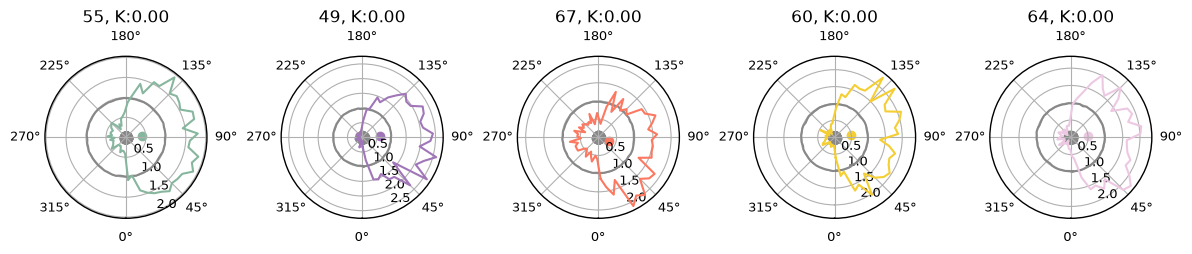

In [20]:
reg = 'nr'
this_K = kuramoto.sel(reg=reg)
this_tc = tuning_curve.sel(reg=reg)
fig, ax = fma.plotting.makeFigure(n=(1,5),size=(30,7),projection='polar')
to_plot = np.random.randint(0,len(this_K.reg),size=5)
for i, e in enumerate(to_plot):
    tk = this_K.isel(reg=e)
    tc = this_tc.isel(reg=e)
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, K:{tk.MC.values:.2f}')
    ax[i].scatter(tk.sel(val='psi',shuf=True),tk.sel(val='R',shuf=True),color=isru.paperColors('shuffle'))
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].scatter(tk.sel(val='psi',shuf=False),tk.sel(val='R',shuf=False),color=isru.paperColors(i))
    ax[i].plot(tuning_curve.phi,tc.sel(shuf=False),color=isru.paperColors(i))

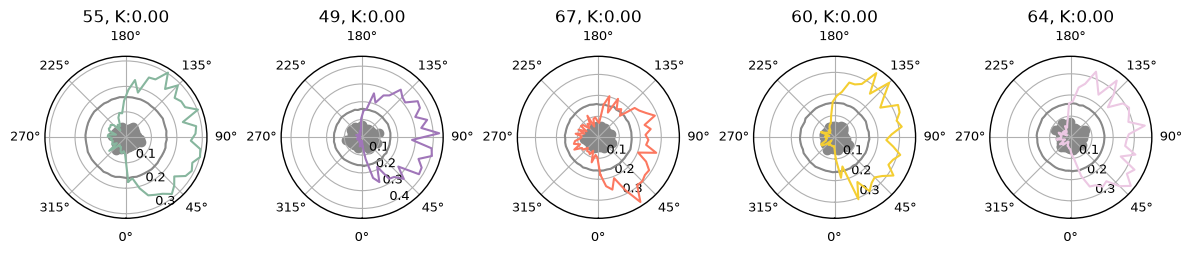

In [23]:
this_tc = dist_transformed.sel(reg=reg)
fig, ax = fma.plotting.makeFigure(n=(1,5),size=(30,7),projection='polar')
for i, e in enumerate(to_plot):
    tk = this_K.isel(reg=e)
    tc = this_tc.isel(reg=e)
    ax[i].set_theta_zero_location('S')
    ax[i].set_title(f'{e}, K:{tk.MC.values:.2f}')
    ax[i].scatter(tk.sel(val='psi',shuf=True),tk.sel(val='R',shuf=True),color=isru.paperColors('shuffle'))
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(dist_transformed.phi,tc.sel(shuf=False),color=isru.paperColors(i))

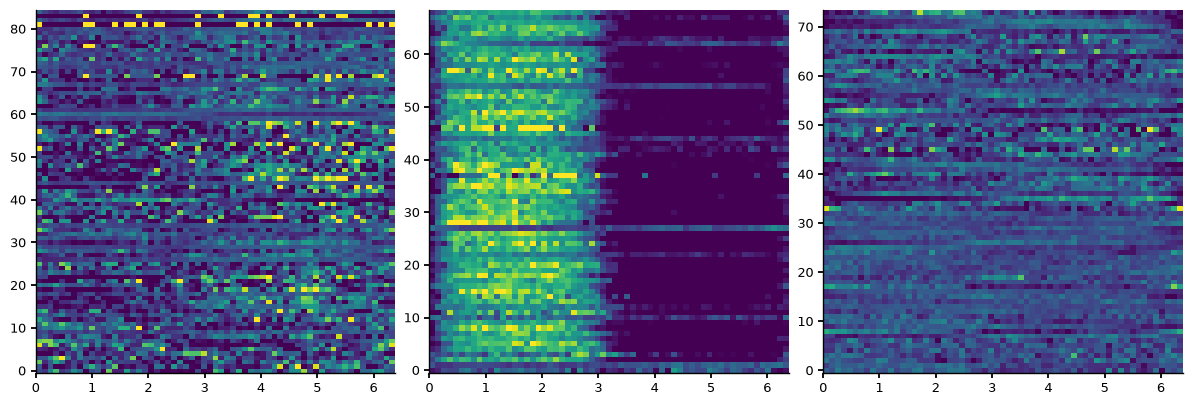

In [30]:
regs = np.unique(dist.reg)
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(30,10))
for i, r in enumerate(regs):
    order = np.argsort(kuramoto.sel(reg=r,val='R'))
    fma.plotting.plotColorMap(tuning_curve.sel(reg=r,shuf=False),sortby=order,x=dist.phi,ax=ax[i],vmin=0.5,vmax=2.5)

run batch

In [ ]:
kuramoto, dist, tuning_curve, dist_transformed, isa_phase = fma.data.runBatch(batch_file,_unitISAPhaseVectorized,kwargs={'shuffle': 1000},parallel=True)
dist_transformed_cat = xr.concat([d for d in dist_transformed if d is not None],dim='reg',join='outer')
#dist_transformed_avg = dist_transformed_cat.groupby('rat').mean(dim='rat',skipna=True)
tuning_curve_cat = xr.concat([d for d in tuning_curve if d is not None],dim='reg',join='outer')
#tuning_curve_avg = tuning_curve_cat.groupby('rat').mean(dim='rat',skipna=True)
kuramoto_cat = xr.concat([d for d in kuramoto if d is not None],dim='reg',join='outer')


Starting Batch, 2026-07-12 14:49:59.236035 

